In [1]:
import os, sys 
os.getcwd()
os.chdir('/Users/eo/Documents/GitHub/OPTOOLS')
sys.path.append('/Users/eo/Documents/GitHub/OPTOOLS/PYTHON')
import numpy as np 
from PYTHON.simulator_functions.generator import surface_from_Z1kxky_uniform_phase
from PYTHON.simulator_functions.spectrum_wrappers import def_spectrum_for_surface
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

/Users/eo/Documents/GitHub/OPTOOLS/PYTHON/wave_physics_functions/spectra.py:133: SyntaxWarning: invalid escape sequence '\ '
  '/!\ Proceed with caution /!\ kX and kY have been flattened to continue running')
/Users/eo/Documents/GitHub/OPTOOLS/PYTHON/wave_physics_functions/spectra.py:133: SyntaxWarning: invalid escape sequence '\ '
  '/!\ Proceed with caution /!\ kX and kY have been flattened to continue running')


ModuleNotFoundError: No module named 'dispersion'

### Example 1

In this first example, we define the wave spectrum *direcly on the $k_x,k_y$ grid* which is the Fourier transform of the $x-y$ grid we want for the sea surface.

In [43]:
# kX, kY : grid of wavenumbers = 2 * pi /wavelength
# steps : dkx and dky, with nx and ny values. dkx = 2*pi/(dx*nx)
# x, y : grid of real x,y : nx values with a dx step. 

noise = 0

## ---  Sea Surface Grid
x_grid_points = 2048; y_grid_points = 2048   # Grid points in x and y directions [count]
x_spacing = 4; y_spacing = 4       # Grid spacing in x and y directions [m]

## --- Spectrum Definition 
mean_direction_degrees = 60                 # Mean direction of the wave spectrum [degrees]
local_depth = 100                           # Local water depth [m]
wave_period = 10                            # Wave period [s]
significant_wave_height = 4                 # Significant wave height [m]
wavelength = 9.81/np.pi*wave_period**2;     # Wavelength assuming deep water 
wavenumber = 2*np.pi/wavelength;            # Wavenumber, k [1/m]

sx=wavenumber*0.1; sy=sx;

Z2D_def, kX, kY = def_spectrum_for_surface(
    # Define the spectrum grid 
    nx = x_grid_points, ny = y_grid_points,
    dx = x_spacing, dy = y_spacing,
    # Define the wave spectrum
    theta_m = mean_direction_degrees,
    D = local_depth,
    T0 = wave_period,
    Hs = significant_wave_height,
    sk_theta = sx, sk_k=sy,
    typeSpec = 'Gaussian')

Gaussian spectrum selected. Available options:
 - Hs, sk_theta, sk_k. 
With (sk_k, sk_theta) the sigma values for the k-axis along the main direction and perpendicular to it respectively 
 Other options (common to all spectrum types) are : nx, ny, dx, dy, T0, theta_m, D
Hs for Gaussian :  4.0


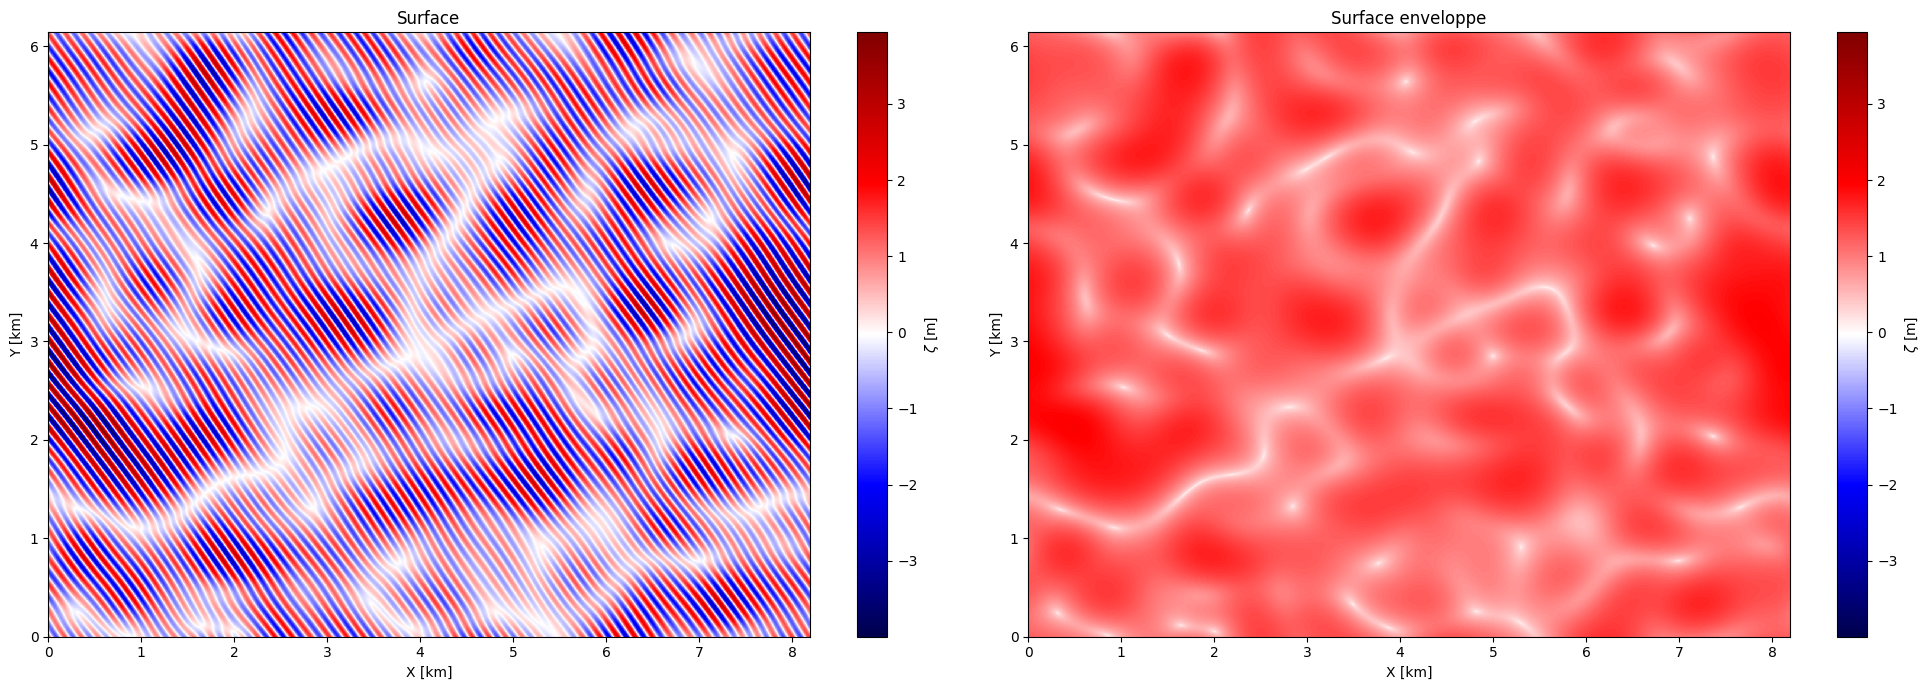

In [44]:
S2D_r, S2D_i, X, Y, kx, rg, dkx, dky = surface_from_Z1kxky_uniform_phase(Z2D_def, kX, kY, 10) 

## Figure Surface et Surface Envelope 
fig,axs=plt.subplots(1,2,figsize=(20,7))        #,sharey=True,sharex=True)

im=axs[0].pcolormesh(X/1000,Y/1000,S2D_r,cmap='seismic',norm = mcolors.Normalize(vmin=S2D_r.min(), vmax=S2D_r.max()))
_=plt.colorbar(im,ax=axs[0],label=r'$\zeta$ [m]')
_=axs[0].set_xlabel(r'X [km]')
_=axs[0].set_ylabel(r'Y [km]')
_=axs[0].set_title(r'Surface')


A = np.sqrt(S2D_r**2+S2D_i**2)
B = np.sqrt(A)

im=axs[1].pcolormesh(X/1000,Y/1000,B,cmap='seismic',norm = mcolors.Normalize(vmin=S2D_r.min(), vmax=S2D_r.max()))
_=plt.colorbar(im,ax=axs[1],label=r'$\zeta$ [m]')

_=axs[1].set_xlabel(r'X [km]')
_=axs[1].set_ylabel(r'Y [km]')
_=axs[1].set_title('Surface enveloppe')
_=plt.tight_layout()